# 1. Introduction

This notebook builds a Logistic Regression model from scratch using only NumPy.
The project uses the Titanic dataset to predict passenger survival.

The notebook includes:

- Data loading
- Data exploration
- Data preprocessing
- Feature scaling
- Logistic Regression implementation using NumPy
- Model evaluation
- ROC Curve visualization
- Feature importance analysis

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 2. Load Dataset

This section loads the Titanic dataset using Pandas and checks:

- Statistical summaries
- Missing values
- Dataset structure

In [22]:
df = pd.read_csv('../data/titanic.csv')

print(df.describe())
print(df.isnull().sum())

              sex         age  family_size       fare   1st_class   2nd_class  \
count  887.000000  887.000000   887.000000  887.00000  887.000000  887.000000   
mean     0.645998   29.471443     0.908681   32.30542    0.243517    0.207441   
std      0.478480   14.121908     1.615949   49.78204    0.429447    0.405703   
min      0.000000    0.420000     0.000000    0.00000    0.000000    0.000000   
25%      0.000000   20.250000     0.000000    7.92500    0.000000    0.000000   
50%      1.000000   28.000000     0.000000   14.45420    0.000000    0.000000   
75%      1.000000   38.000000     1.000000   31.13750    0.000000    0.000000   
max      1.000000   80.000000    10.000000  512.32920    1.000000    1.000000   

        3rd_class    survived  
count  887.000000  887.000000  
mean     0.549042    0.385569  
std      0.497870    0.487004  
min      0.000000    0.000000  
25%      0.000000    0.000000  
50%      1.000000    0.000000  
75%      1.000000    1.000000  
max      1.000

# 3. Data Exploration

This section explores relationships between features and survival.

The visualizations include:

- Survival rates by passenger category
- Age distribution
- Survival count across age groups
- Correlation heatmap

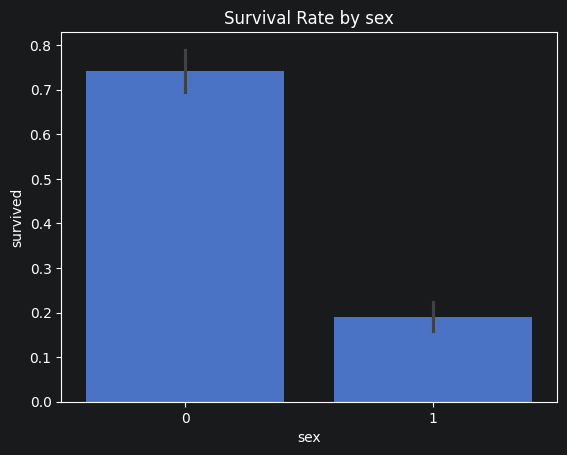

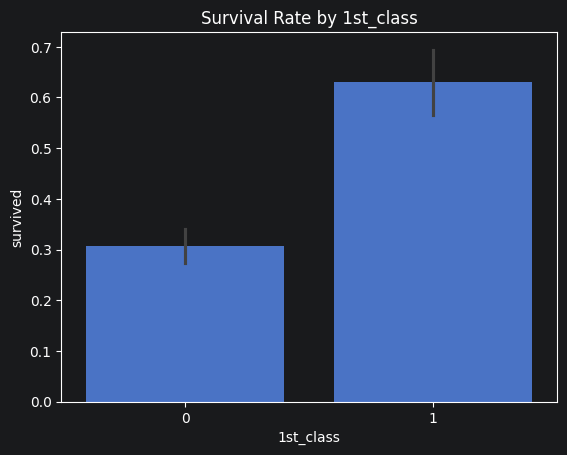

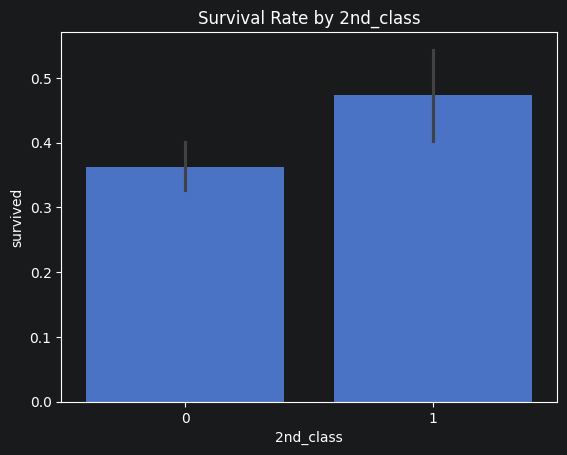

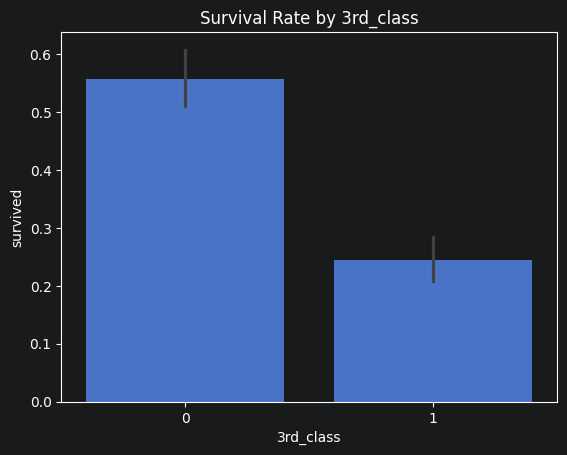

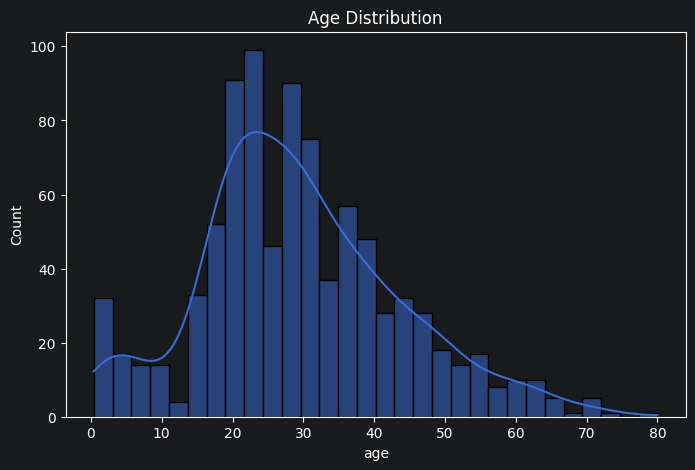

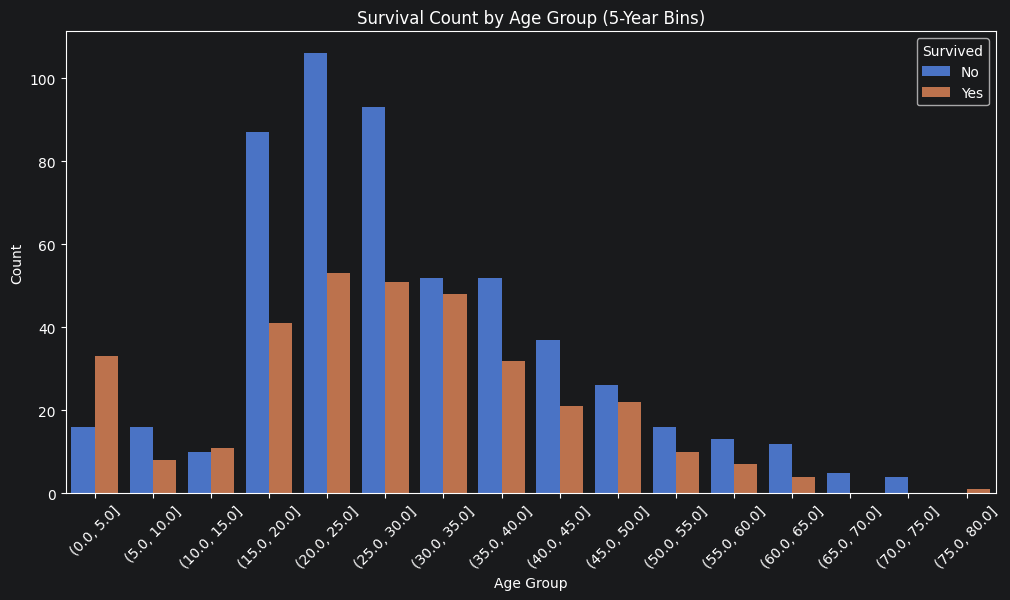

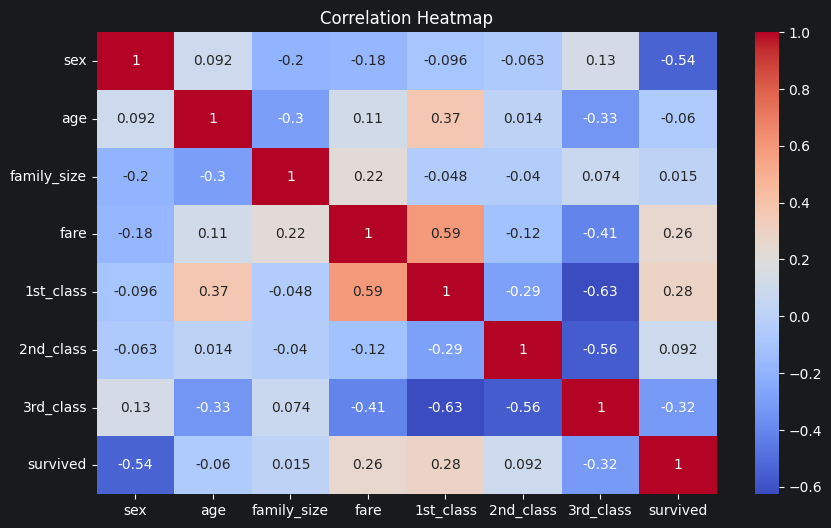

In [23]:
numeric_features = ["age", "family_size", "fare"]
binary_features = ["sex", "1st_class", "2nd_class", "3rd_class"]

for feature in df.columns:
    if feature in binary_features:
        sns.barplot(x=feature, y='survived', data=df)
        plt.title(f'Survival Rate by {feature}')
        plt.show()

# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

# Age group by survivors
viz_df = df.copy()
bins = np.arange(0, viz_df['age'].max() + 5, 5)

viz_df['age_group'] = pd.cut(viz_df['age'], bins=bins)

plt.figure(figsize=(12,6))

sns.countplot(
    data=viz_df,
    x='age_group',
    hue='survived'
)

plt.xticks(rotation=45)
plt.title('Survival Count by Age Group (5-Year Bins)')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

# Correlation heatmap
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 4. Data Cleaning and Preprocessing

This section prepares the dataset for training.

The steps include:

- Selecting features
- Separating target variable
- Converting data to NumPy arrays


In [24]:
# convert df to numpy
X_df = df.drop(columns=['survived', '2nd_class', 'family_size'])
X = X_df.values
y = df['survived'].values


# 5. Train Test Split Using NumPy

This section manually splits the dataset into:

- Training set (80%)
- Testing set (20%)

In [25]:
def train_test_split_numpy(X, y, test_size=0.2, random_state=42):
    np.random.seed(random_state)

    indices = np.arange(len(X))
    np.random.shuffle(indices)

    split_index = int(len(X) * (1 - test_size))

    train_indices = indices[:split_index]
    test_indices = indices[split_index:]

    return (
        X[train_indices],
        X[test_indices],
        y[train_indices],
        y[test_indices]
    )

X_train, X_test, y_train, y_test = train_test_split_numpy(X, y)

# 6. Standard Scaler (Numpy Implementation)

This section implements feature standardization using NumPy.
The mean and standard deviation are calculated from the training data, and numerical features are scaled using the standardization formula:

Gradient descent converges much faster when features are on a similar scale.
We standardize each feature to have zero mean and unit variance:

$$
x_j^{\prime} = \frac{x_j - \mu_j}{\sigma_j}
$$

We fit the statistics on the **training set only** and apply them to both sets
to avoid data leakage.



In [26]:
numeric_indices = [1, 2]  # age, fare

def standardize_fit(X, numeric_indices):
    means = np.mean(X[:, numeric_indices], axis=0)
    stds = np.std(X[:, numeric_indices], axis=0)

    print(means, stds)

    return means, stds

def standardize_transform(X, numeric_indices, means, stds):
    X_copy = X.copy().astype(float)

    X_copy[:, numeric_indices] = (
        X_copy[:, numeric_indices] - means
    ) / stds

    return X_copy

means, stds = standardize_fit(X_train, numeric_indices)

X_train_scaled = standardize_transform(
    X_train,
    numeric_indices,
    means,
    stds
)

X_test_scaled = standardize_transform(
    X_test,
    numeric_indices,
    means,
    stds
)

[29.45803949 31.01366262] [14.18434519 47.89676385]


# 7. Logistic Regression

This section implements Logistic Regression from scratch using NumPy.
The model learns a linear decision boundary for binary classification using gradient descent optimization.

The sigmoid function converts linear predictions into probabilities between 0 and 1:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Binary cross-entropy loss is used to measure prediction error, while L2 regularization helps reduce overfitting.

In [34]:
class LogisticRegressionScratch:

    def __init__(
        self,
        learning_rate=0.01,
        epochs=5000,
        C=1.0,
        fit_intercept=True
    ):

        self.learning_rate = learning_rate
        self.epochs = epochs
        self.C = C
        self.fit_intercept = fit_intercept
        self.loss_history = []
        self.weights = None
        self.bias = None

    def sigmoid(self, z):

        return np.where(
            z >= 0,
            1 / (1 + np.exp(-z)),
            np.exp(z) / (1 + np.exp(z))
        )


    def compute_loss(self, y, y_hat):

        epsilon = 1e-15

        y_hat = np.clip(y_hat, epsilon, 1 - epsilon)

        data_loss = -np.mean(
            y * np.log(y_hat) +
            (1 - y) * np.log(1 - y_hat)
        )

        # L2 regularization term
        reg_loss = (1 / (2 * self.C * len(y))) * np.sum(self.weights ** 2)

        return data_loss + reg_loss


    def fit(self, X, y):

        n_samples, n_features = X.shape

        # Better initialization
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0

        for epoch in range(self.epochs):

            # Linear combination
            linear_model = np.dot(X, self.weights)

            if self.fit_intercept:
                linear_model += self.bias

            # Probabilities
            y_hat = self.sigmoid(linear_model)

            # Errors
            errors = y_hat - y

            # Gradients
            dw = (1 / n_samples) * np.dot(X.T, errors)

            # Add L2 regularization gradient
            dw += (1 / (self.C * n_samples)) * self.weights

            db = (1 / n_samples) * np.sum(errors)

            # Parameter updates
            self.weights -= self.learning_rate * dw

            if self.fit_intercept:
                self.bias -= self.learning_rate * db

            if epoch % 50 == 0:

                loss = self.compute_loss(y, y_hat)
                self.loss_history.append(loss)

                print(f"Epoch {epoch} | Loss: {loss:.6f}")

    def predict_proba(self, X):

        linear_model = np.dot(X, self.weights)

        if self.fit_intercept:
            linear_model += self.bias

        return self.sigmoid(linear_model)

    def predict(self, X, threshold=0.5):

        probabilities = self.predict_proba(X)

        return (probabilities >= threshold).astype(int)

# 8. Model Training

This section initializes and trains the Logistic Regression model using the scaled training data.

During each epoch:
- Predictions are generated
- Loss is calculated
- Gradients are computed
- Weights and bias are updated using gradient descent

The loss value is printed periodically to monitor convergence during training.

In [35]:
model = LogisticRegressionScratch(
    learning_rate=0.5,
    epochs=500,
    C=10.0
)

model.fit(X_train_scaled, y_train)


Epoch 0 | Loss: 0.694222
Epoch 50 | Loss: 0.482402
Epoch 100 | Loss: 0.461347
Epoch 150 | Loss: 0.454742
Epoch 200 | Loss: 0.452410
Epoch 250 | Loss: 0.451528
Epoch 300 | Loss: 0.451179
Epoch 350 | Loss: 0.451035
Epoch 400 | Loss: 0.450973
Epoch 450 | Loss: 0.450947


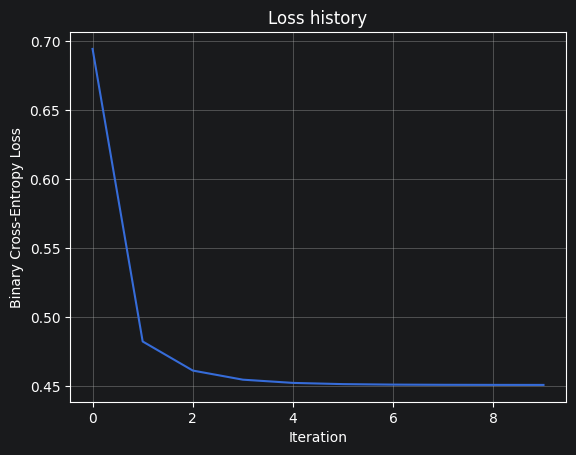

In [36]:
plt.plot(model.loss_history)
plt.title("Loss history")
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid()
plt.show()

# 9. Predictions

After training, the model is used to generate:
- Predicted probabilities using `predict_proba()`
- Final binary predictions using `predict()`

A threshold of 0.5 is used to classify samples into class 0 or class 1.

In [29]:
y_prob = model.predict_proba(X_test_scaled)
y_pred = model.predict(X_test_scaled)


# 10. Evaluation Metrics (NumPy Implementation)

This section implements common classification metrics using only NumPy.

The following metrics are calculated:
- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1 Score
- ROC Curve
- ROC AUC Score

These metrics help evaluate how well the model performs on unseen test data.

In [30]:
def confusion_matrix_numpy(y_true, y_pred):

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    return np.array([
        [tn, fp],
        [fn, tp]
    ])

def accuracy_score_numpy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def precision_score_numpy(y_true, y_pred):

    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))

    return tp / (tp + fp + 1e-15)

def recall_score_numpy(y_true, y_pred):

    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    return tp / (tp + fn + 1e-15)

def f1_score_numpy(y_true, y_pred):

    precision = precision_score_numpy(y_true, y_pred)
    recall = recall_score_numpy(y_true, y_pred)

    return 2 * (precision * recall) / (precision + recall + 1e-15)

def roc_curve_numpy(y_true, y_scores):

    thresholds = np.sort(np.unique(y_scores))[::-1]

    tpr_list = []
    fpr_list = []

    for threshold in thresholds:

        y_pred = (y_scores >= threshold).astype(int)

        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        tn = np.sum((y_true == 0) & (y_pred == 0))

        tpr = tp / (tp + fn + 1e-15)
        fpr = fp / (fp + tn + 1e-15)

        tpr_list.append(tpr)
        fpr_list.append(fpr)

    return np.array(fpr_list), np.array(tpr_list), thresholds

def roc_auc_score_numpy(fpr, tpr):
    return np.trapz(tpr, fpr)

# 11. Model Evaluation

This section evaluates the trained model using the previously implemented metrics.

The confusion matrix is visualized using a heatmap, while accuracy, precision, recall, F1-score, and ROC AUC values are printed to summarize model performance.

[[88 18]
 [20 52]]


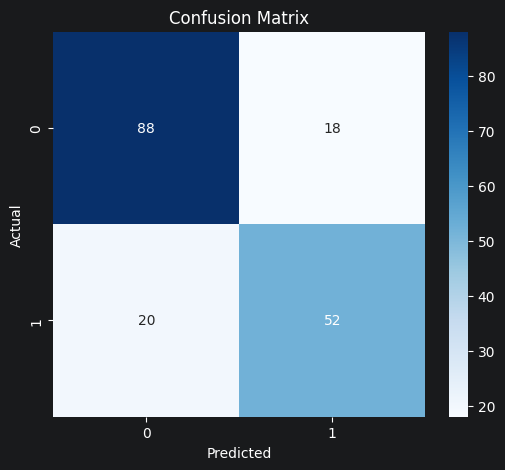


===== METRICS =====
Accuracy Score : 0.79
Precision Score: 0.74
Recall Score   : 0.72
F1 Score       : 0.73
ROC AUC Score  : 0.85


In [31]:
cm = confusion_matrix_numpy(y_test, y_pred)

print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

accuracy = accuracy_score_numpy(y_test, y_pred)
precision = precision_score_numpy(y_test, y_pred)
recall = recall_score_numpy(y_test, y_pred)
f1 = f1_score_numpy(y_test, y_pred)

fpr, tpr, thresholds = roc_curve_numpy(y_test, y_prob)
roc_auc = roc_auc_score_numpy(fpr, tpr)

print("\n===== METRICS =====")
print(f"Accuracy Score : {accuracy:.2f}")
print(f"Precision Score: {precision:.2f}")
print(f"Recall Score   : {recall:.2f}")
print(f"F1 Score       : {f1:.2f}")
print(f"ROC AUC Score  : {roc_auc:.2f}")

# 12. ROC Curve

This section visualizes the Receiver Operating Characteristic (ROC) Curve.

The ROC curve shows the trade-off between:
- True Positive Rate (TPR)
- False Positive Rate (FPR)

The Area Under the Curve (AUC) provides a single value summarizing the model’s classification performance across all thresholds.

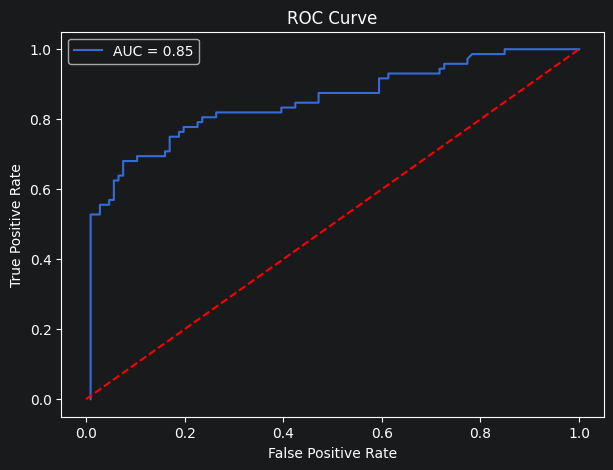

In [32]:
plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='red'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 13. Feature Importance

This section analyzes feature importance using the learned Logistic Regression coefficients.

Features with larger positive or negative coefficients have a stronger influence on the model’s predictions. The coefficients are visualized using a bar plot for easier interpretation.


===== FEATURE IMPORTANCE =====
     Feature  Coefficient
3  1st_class     1.192382
2       fare     0.117392
1        age    -0.433674
4  3rd_class    -1.186491
0        sex    -2.536280


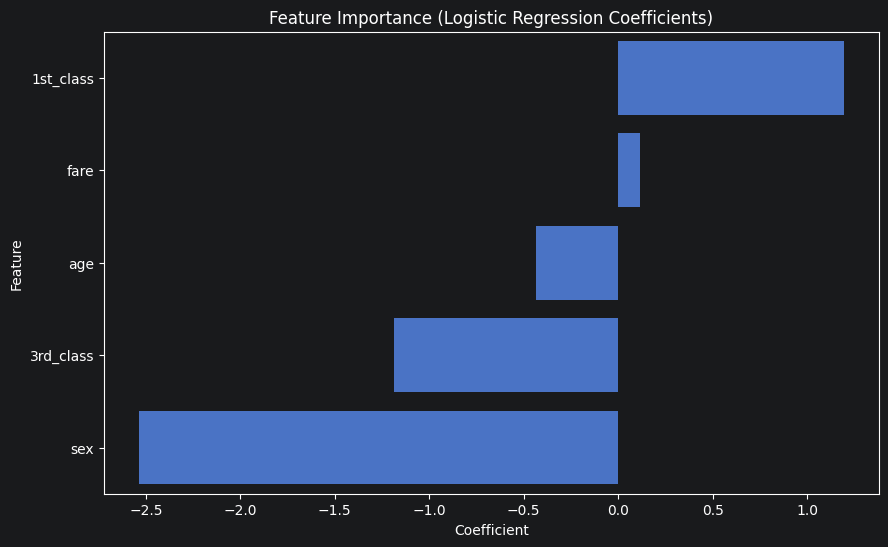

In [33]:
coefficients = pd.DataFrame({
    'Feature': X_df.columns,
    'Coefficient': model.weights
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

print("\n===== FEATURE IMPORTANCE =====")
print(coefficients)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=coefficients
)

plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.show()